In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load (no trust_remote_code)
dataset = load_dataset('descartes100/enhanced-financial-phrasebank')
print("Dataset:", dataset)

# Handle nested structure: df['train'] is dict-like rows
rows = dataset['train']['train']
df = pd.DataFrame(rows)
label_names = ['negative', 'neutral', 'positive']

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Labels:\n", df['label'].value_counts().sort_index().to_dict())

X = df['sentence']
y = df['label']

# Split & vectorize
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
vectorizer = TfidfVectorizer(max_features=2000, stop_words='english', min_df=2, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vectorizer shape:", X_train_vec.shape)

Dataset: DatasetDict({
    train: Dataset({
        features: ['train'],
        num_rows: 4846
    })
})
Shape: (4846, 2)
Columns: ['label', 'sentence']
Labels:
 {0: 604, 1: 2879, 2: 1363}
Vectorizer shape: (3876, 2000)


##### Naive Bayes


MultinomialNB Results:
Accuracy: 0.7392
              precision    recall  f1-score   support

    negative       0.78      0.74      0.76       121
     neutral       0.74      0.90      0.81       576
    positive       0.72      0.40      0.51       273

    accuracy                           0.74       970
   macro avg       0.75      0.68      0.69       970
weighted avg       0.74      0.74      0.72       970



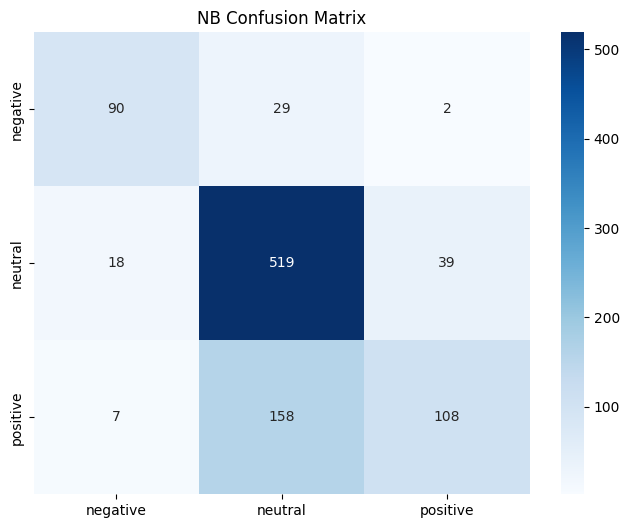

In [2]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB(alpha=1.0, class_prior=None) 
model_nb.fit(X_train_vec, y_train)
y_pred_nb = model_nb.predict(X_test_vec)

print("\nMultinomialNB Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb, target_names=label_names))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('NB Confusion Matrix')
# plt.savefig('twitter_nb_cm.png', dpi=300)
plt.show()


##### Logistic Regression


Logistic Regression Results:
Accuracy: 0.7402
              precision    recall  f1-score   support

    negative       0.85      0.67      0.75       121
     neutral       0.74      0.88      0.80       576
    positive       0.68      0.48      0.56       273

    accuracy                           0.74       970
   macro avg       0.76      0.68      0.71       970
weighted avg       0.74      0.74      0.73       970



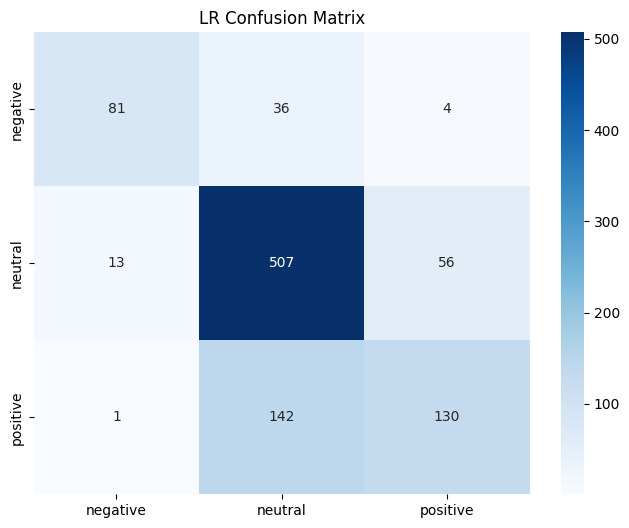

In [3]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, random_state=67)
model_lr.fit(X_train_vec, y_train)
y_pred_lr = model_lr.predict(X_test_vec)

print("\nLogistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=label_names))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('LR Confusion Matrix')
# plt.savefig('twitter_lr_cm.png', dpi=300)
plt.show()

##### SVM


SVM Results:
Accuracy: 0.7371
              precision    recall  f1-score   support

    negative       0.80      0.75      0.77       121
     neutral       0.74      0.86      0.80       576
    positive       0.68      0.47      0.56       273

    accuracy                           0.74       970
   macro avg       0.74      0.69      0.71       970
weighted avg       0.73      0.74      0.73       970



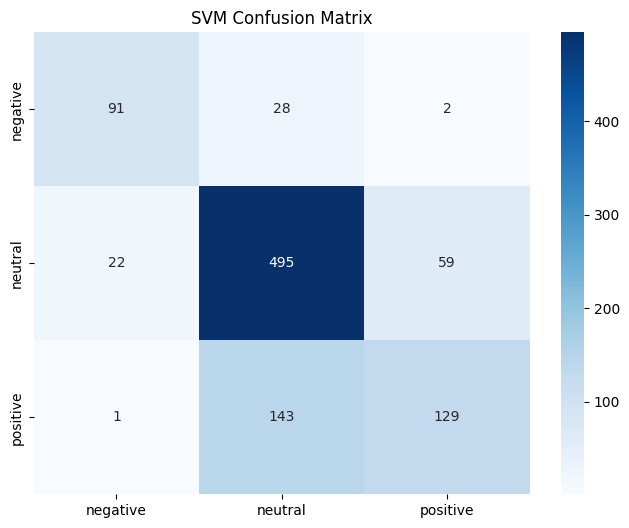

In [4]:
from sklearn.svm import SVC

model_svm = SVC(kernel='linear', random_state=67, probability=True)
model_svm.fit(X_train_vec, y_train)
y_pred_svm = model_svm.predict(X_test_vec)

print("\nSVM Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=label_names))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('SVM Confusion Matrix')
# plt.savefig('twitter_svm_cm.png', dpi=300)
plt.show()